## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


### Find no.of samples are there in training and test datasets

In [3]:
print (x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [4]:
print (y_train.shape, y_test.shape)

(60000,) (10000,)


### Find dimensions of an image in the dataset

In [5]:
x_train[0].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [6]:
from keras.utils import np_utils
y_train = np_utils.to_categorical(y_train, 10)
y_test = np_utils.to_categorical(y_test, 10)

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [7]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32')

### Normalize both the train and test image data from 0-255 to 0-1

In [8]:
x_train /= 255
x_test /= 255

### Import the necessary layers from keras to build the model

In [9]:
import keras
from keras.datasets import cifar10, mnist
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Reshape
from keras.layers import Convolution2D, MaxPooling2D
from keras.utils import np_utils

### Build a model 

** with 2 Conv layers having `32 3*3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [10]:
TRAIN = True
BATCH_SIZE = 32
EPOCHS = 10


if TRAIN:
    # Define model
    model2 = Sequential()

    # 1st Conv Layer
    model2.add(Convolution2D(32, 3, 3, input_shape=(28, 28, 1)))
    model2.add(Activation('relu'))

    # 2nd Conv Layer
    model2.add(Convolution2D(32, 3, 3))
    model2.add(Activation('relu'))

    # Fully Connected Layer
    model2.add(Flatten())
    model2.add(Dense(128))
    model2.add(Activation('relu'))

    # Prediction Layer
    model2.add(Dense(10))
    model2.add(Activation('softmax'))

    # Loss and Optimizer
    model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # Store Training Results
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_acc', patience=5, verbose=1, mode='auto')
    callback_list = [early_stopping]

    # Train the model2
    model2.fit(x_train, y_train, batch_size=BATCH_SIZE, nb_epoch=EPOCHS, 
              validation_data=(x_test, y_test), callbacks=callback_list)
    
    # Save model2 and Stats
    model2.save('./basic_cnn.h5')

else:
    print('Loading pretrained model...')
    model2 = keras.models.load_model('./basic_cnn.h5')
    print('Model Loaded.')

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Use tf.cast instead.
Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 123s 2ms/step - loss: 0.3735 - acc: 0.8653 - val_loss: 0.2936 - val_acc: 0.8940
Epoch 2/10
60000/60000 [==============================] - 123s 2ms/step - loss: 0.2289 - acc: 0.9157 - val_loss: 0.2501 - val_acc: 0.9121
Epoch 3/10
60000/60000 [==============================] - 122s 2ms/step - loss: 0.1674 - acc: 0.9377 - val_loss: 0.2586 - val_acc: 0.9133
Epoch 4/10
60000/60000 [==============================] - 122s 2ms/step - loss: 0.1161 - acc: 0.9565 - val_loss: 0.2893 - val_acc: 0.9108
Epoch 5/10
60000/60000 [==============================] - 122s 2ms/step - loss: 0.0790 - acc: 0.9705 - val_loss: 0.3111 - val_acc: 0.9145
Epoch 6/10
60000/60000 [==============================] - 122s 2ms/step - loss: 0.0519 - acc: 0.9809 - val_loss: 0.3478 - val_acc: 0.9130
Ep

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [11]:
# Deine Model
model3 = Sequential()

# 1st Conv Layer
model3.add(Convolution2D(32, 3, 3, input_shape=(28, 28, 1)))
model3.add(Activation('relu'))

# 2nd Conv Layer
model3.add(Convolution2D(32, 3, 3))
model3.add(Activation('relu'))

# Max Pooling
model3.add(MaxPooling2D(pool_size=(2,2)))

# Dropout
model3.add(Dropout(0.25))

# Fully Connected Layer
model3.add(Flatten())
model3.add(Dense(128))
model3.add(Activation('relu'))

# More Dropout
model3.add(Dropout(0.5))

# Prediction Layer
model3.add(Dense(10))
model3.add(Activation('softmax'))

# Loss and Optimizer
model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Store Training Results
early_stopping = keras.callbacks.EarlyStopping(monitor='val_acc', patience=5, verbose=1, mode='auto')
callback_list = [early_stopping]

# Train the model
model3.fit(x_train, y_train, batch_size=BATCH_SIZE, nb_epoch=EPOCHS, 
          validation_data=(x_test, y_test), callbacks=callback_list)

# Save model and Stats

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 88s 1ms/step - loss: 0.4994 - acc: 0.8243 - val_loss: 0.3237 - val_acc: 0.8767
Epoch 2/10
60000/60000 [==============================] - 88s 1ms/step - loss: 0.3386 - acc: 0.8780 - val_loss: 0.2835 - val_acc: 0.8944
Epoch 3/10
60000/60000 [==============================] - 88s 1ms/step - loss: 0.2927 - acc: 0.8941 - val_loss: 0.2562 - val_acc: 0.9059
Epoch 4/10
60000/60000 [==============================] - 88s 1ms/step - loss: 0.2609 - acc: 0.9046 - val_loss: 0.2353 - val_acc: 0.9105
Epoch 5/10
60000/60000 [==============================] - 88s 1ms/step - loss: 0.2407 - acc: 0.9123 - val_loss: 0.2236 - val_acc: 0.9200
Epoch 6/10
60000/60000 [==============================] - 88s 1ms/step - loss: 0.2222 - acc: 0.9170 - val_loss: 0.2241 - val_acc: 0.9177
Epoch 7/10
60

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [12]:
from keras.preprocessing.image import ImageDataGenerator

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

In [13]:
from keras.preprocessing.image import ImageDataGenerator

# This will do preprocessing and realtime data augmentation:
datagen = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # apply ZCA whitening
    rotation_range=50,  # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=False,  # randomly flip images
    vertical_flip=False)  # randomly flip images

# Prepare the generator
datagen.fit(x_train)

In [14]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

<Figure size 640x480 with 5 Axes>

### Run the above model using fit_generator()

In [15]:
TRAIN= True

model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
if TRAIN:
    model3.fit_generator(datagen.flow(x_train, y_train,
                        batch_size=BATCH_SIZE),
                        samples_per_epoch=x_train.shape[0],
                        nb_epoch=EPOCHS,
                        validation_data=(x_test, y_test), callbacks=callback_list)
    model3.save('./cnn_augment.h5')
else:
    print('Loading pretrained model...')
    model3 = keras.models.load_model('./cnn_augment.h5')
    print('Model Loaded.')

Epoch 1/10
1875/1875 [==============================] - 96s 51ms/step - loss: 0.9223 - acc: 0.6649 - val_loss: 0.3725 - val_acc: 0.8646
Epoch 2/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.6781 - acc: 0.7492 - val_loss: 0.3615 - val_acc: 0.8704
Epoch 3/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.6171 - acc: 0.7720 - val_loss: 0.3714 - val_acc: 0.8656
Epoch 4/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.5842 - acc: 0.7849 - val_loss: 0.3732 - val_acc: 0.8703
Epoch 5/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.5634 - acc: 0.7944 - val_loss: 0.3665 - val_acc: 0.8709
Epoch 6/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.5422 - acc: 0.7998 - val_loss: 0.3619 - val_acc: 0.8699
Epoch 7/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.5263 - acc: 0.8059 - val_loss: 0.3438 - val_acc: 0.8793
Epoch 8/10
1875/1875 [==========================

###  Report the final train and validation accuracy

In [16]:
loss_and_metrics = model3.evaluate(x_train, y_train)
print(loss_and_metrics)

60000/60000 [==============================] - 21s 353us/step
[0.30160964472989243, 0.8891333333333333]


In [17]:
loss_and_metrics = model3.evaluate(x_test, y_test)
print(loss_and_metrics)

10000/10000 [==============================] - 4s 352us/step
[0.3450024874448776, 0.8761]


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [18]:
from keras.datasets import cifar10
import numpy as np

### **Load CIFAR10 dataset**

In [19]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data() # fetch CIFAR-10 data

170500096/170498071 [==============================] - 8s 0us/step


In [20]:
num_train, depth, height, width = X_train.shape # there are 50000 training examples in CIFAR-10 
num_test = X_test.shape[0] # there are 10000 test examples in CIFAR-10
num_classes = np.unique(y_train).shape[0]

X_train = X_train.astype('float32') 
X_test = X_test.astype('float32')
X_train /= np.max(X_train) # Normalise data to [0, 1] range
X_test /= np.max(X_train) # Normalise data to [0, 1] range

y_train = np_utils.to_categorical(y_train, num_classes) # One-hot encode the labels
y_test = np_utils.to_categorical(y_test, num_classes) 

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [21]:
from keras.preprocessing.image import ImageDataGenerator

# This will do preprocessing and realtime data augmentation:
datagen = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # apply ZCA whitening
    rotation_range=50,  # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=True,  # randomly flip images
    vertical_flip=False)  # randomly flip images

# Prepare the generator
datagen.fit(X_train)

### **Prepare/fit the generator.**

In [22]:
from keras.datasets import cifar10 # subroutines for fetching the CIFAR-10 dataset
from keras.models import Model # basic class for specifying and training a neural network
from keras.layers import Input, Convolution2D, MaxPooling2D, Dense, Dropout, Activation, Flatten
from keras.utils import np_utils # utilities for one-hot encoding of ground truth values
import numpy as np

batch_size = 32 # in each iteration, we consider 32 training examples at once
num_epochs = 2 # we iterate 20 times over the entire training set
kernel_size = 3 # we will use 3x3 kernels throughout
pool_size = 2 # we will use 2x2 pooling throughout
conv_depth_1 = 32 # we will initially have 32 kernels per conv. layer...
conv_depth_2 = 64 # ...switching to 64 after the first pooling layer
drop_prob_1 = 0.25 # dropout after pooling with probability 0.25
drop_prob_2 = 0.5 # dropout in the FC layer with probability 0.5
hidden_size = 512 # the FC layer will have 512 neurons

In [23]:
inp = Input(shape=(depth, height, width)) # N.B. depth goes first in Keras!
# Conv [32] -> Conv [32] -> Pool (with dropout on the pooling layer)
conv_1 = Convolution2D(conv_depth_1, kernel_size, kernel_size, border_mode='same', activation='relu')(inp)
conv_2 = Convolution2D(conv_depth_1, kernel_size, kernel_size, border_mode='same', activation='relu')(conv_1)
pool_1 = MaxPooling2D(pool_size=(pool_size, pool_size))(conv_2)
drop_1 = Dropout(drop_prob_1)(pool_1)
# Conv [64] -> Conv [64] -> Pool (with dropout on the pooling layer)
conv_3 = Convolution2D(conv_depth_2, kernel_size, kernel_size, border_mode='same', activation='relu')(drop_1)
conv_4 = Convolution2D(conv_depth_2, kernel_size, kernel_size, border_mode='same', activation='relu')(conv_3)
pool_2 = MaxPooling2D(pool_size=(pool_size, pool_size))(conv_4)
drop_2 = Dropout(drop_prob_1)(pool_2)
# Now flatten to 1D, apply FC -> ReLU (with dropout) -> softmax
flat = Flatten()(drop_2)
hidden = Dense(hidden_size, activation='relu')(flat)
drop_3 = Dropout(drop_prob_2)(hidden)
out = Dense(num_classes, activation='softmax')(drop_3)

model = Model(input=inp, output=out) # To define a model, just specify its input and output layers

model.compile(loss='categorical_crossentropy', # using the cross-entropy loss function
              optimizer='adam', # using the Adam optimiser
              metrics=['accuracy']) # reporting the accuracy


In [24]:
model.fit_generator(datagen.flow(X_train, y_train,
                        batch_size=BATCH_SIZE),
                        samples_per_epoch=X_train.shape[0],
                        nb_epoch=EPOCHS,
                        validation_data=(X_test, y_test), callbacks=callback_list)

Epoch 1/10
1562/1562 [==============================] - 293s 187ms/step - loss: 1.7593 - acc: 0.3543 - val_loss: 10.6447 - val_acc: 0.3292
Epoch 2/10
1562/1562 [==============================] - 288s 184ms/step - loss: 1.4784 - acc: 0.4644 - val_loss: 11.0278 - val_acc: 0.3075
Epoch 3/10
1562/1562 [==============================] - 291s 186ms/step - loss: 1.3672 - acc: 0.5096 - val_loss: 10.6805 - val_acc: 0.3258
Epoch 4/10
1562/1562 [==============================] - 288s 185ms/step - loss: 1.2903 - acc: 0.5393 - val_loss: 10.4462 - val_acc: 0.3423
Epoch 5/10
1562/1562 [==============================] - 288s 185ms/step - loss: 1.2412 - acc: 0.5572 - val_loss: 10.5965 - val_acc: 0.3356
Epoch 6/10
1562/1562 [==============================] - 291s 186ms/step - loss: 1.2139 - acc: 0.5696 - val_loss: 10.7265 - val_acc: 0.3277
Epoch 7/10
1562/1562 [==============================] - 292s 187ms/step - loss: 1.1855 - acc: 0.5774 - val_loss: 11.4398 - val_acc: 0.2828
Epoch 8/10
1562/1562 [=====

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

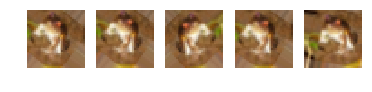

In [25]:
from matplotlib import pyplot as plt
gen = datagen.flow(X_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()